In [2]:
pip install yfinance pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\vipul\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf
import pandas as pd

aapl = yf.download('AAPL',start = '2024-01-01',end = '2026-05-01')

msft = yf.download('MSFT',start = '2024-01-01',end = '2026-05-01')

nvda = yf.download('NVDA',start = '2024-01-01',end = '2026-05-01')

close = pd.DataFrame()

close['AAPL'] = aapl['Close'].squeeze()
close['MSFT'] = msft['Close'].squeeze()
close['NVDA'] = nvda['Close'].squeeze()

print(close.head())


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  AAPL        MSFT       NVDA
2024-01-02  183.562195  363.801483  48.138569
2024-01-03  182.187714  363.536682  47.539936
2024-01-04  179.873947  360.927338  47.968681
2024-01-05  179.152100  360.740997  49.067013
2024-01-08  183.483093  367.548706  52.221077


In [4]:
close.isnull().sum()

AAPL    0
MSFT    0
NVDA    0
dtype: int64

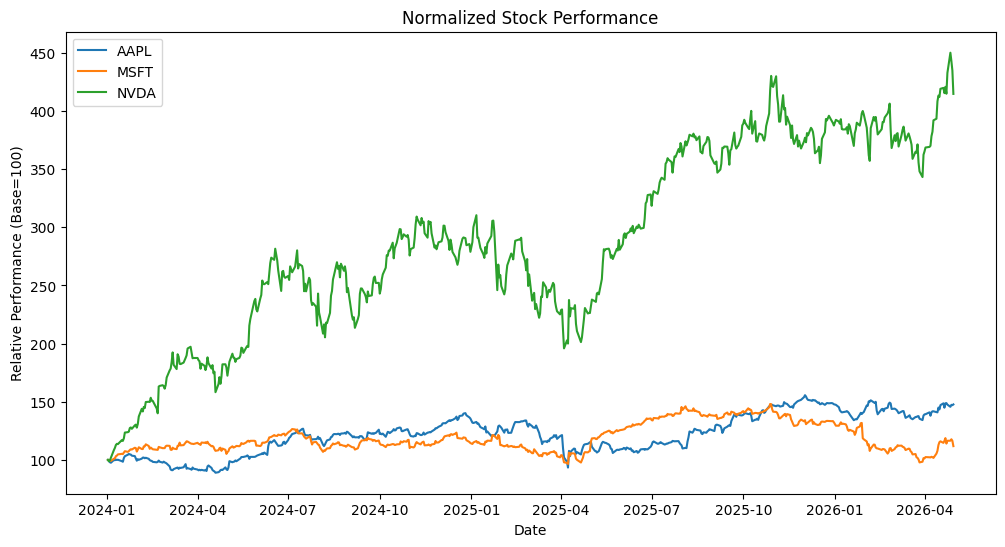

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

normalized = close/close.iloc[0]*100

plt.figure(figsize=(12,6))
plt.plot(normalized['AAPL'],label='AAPL')
plt.plot(normalized['MSFT'],label='MSFT')
plt.plot(normalized['NVDA'],label='NVDA')

plt.title("Normalized Stock Performance")
plt.xlabel("Date")
plt.ylabel("Relative Performance (Base=100)")
plt.legend()
plt.savefig("normalized_trend.png",bbox_inches='tight')
plt.show()

In [13]:
plt.savefig("normalized_trend.png")

<Figure size 640x480 with 0 Axes>

Pattern 1: NVIDIA significantly outperformed other technology stocks

Observation: After normalizing all stocks to the same starting value (Base = 100), NVIDIA increased to approximately 450, while Apple and Microsoft reached only around 150.

Interpretation: NVIDIA generated substantially higher returns during the observed period, likely due to strong market demand for AI-related technologies. However, its price movement also displayed larger fluctuations, indicating higher volatility and risk.

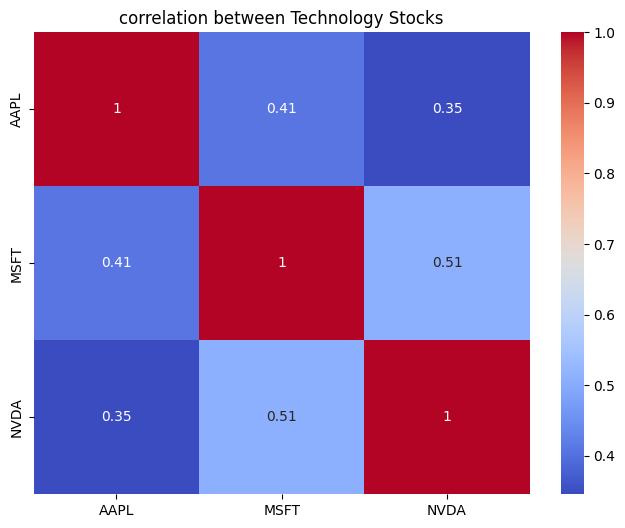

In [15]:
returns = close.pct_change()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("correlation between Technology Stocks")
plt.savefig("correlation_heatmap.png",bbox_inches='tight')
plt.show()

Pattern 2: Moderate positive correlation among technology stocks

Observation: The correlation analysis indicates that all three technology stocks move in the same general direction, but the strength of the relationship differs.

Key findings:

Microsoft–NVIDIA correlation ≈ 0.51
Apple–Microsoft correlation ≈ 0.41
Apple–NVIDIA correlation ≈ 0.35

Interpretation:Technology stocks are affected by common sector and market factors, but they do not move identically. This suggests that diversification within the technology sector may reduce some risk while still maintaining exposure to the industry.

<Figure size 1200x600 with 0 Axes>

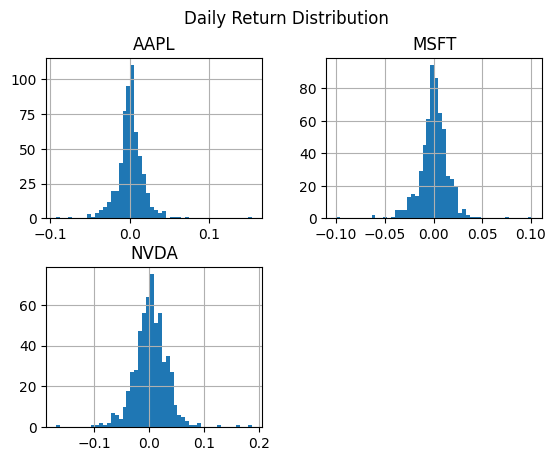

In [17]:
returns = close.pct_change()

plt.figure(figsize=(12,6))

returns.hist(bins=50)

plt.suptitle("Daily Return Distribution")
plt.savefig("return_distribution.png",bbox_inches="tight")
plt.show()

Pattern 3: NVIDIA exhibits higher volatility than Apple and Microsoft

Observation:The daily return distribution shows that NVIDIA has a wider spread of returns compared with Apple and Microsoft. Apple and Microsoft returns are concentrated more closely around zero.

Interpretation:A wider return distribution indicates higher volatility. While NVIDIA may provide higher potential returns, it also experiences larger day-to-day price movements and therefore carries greater risk.

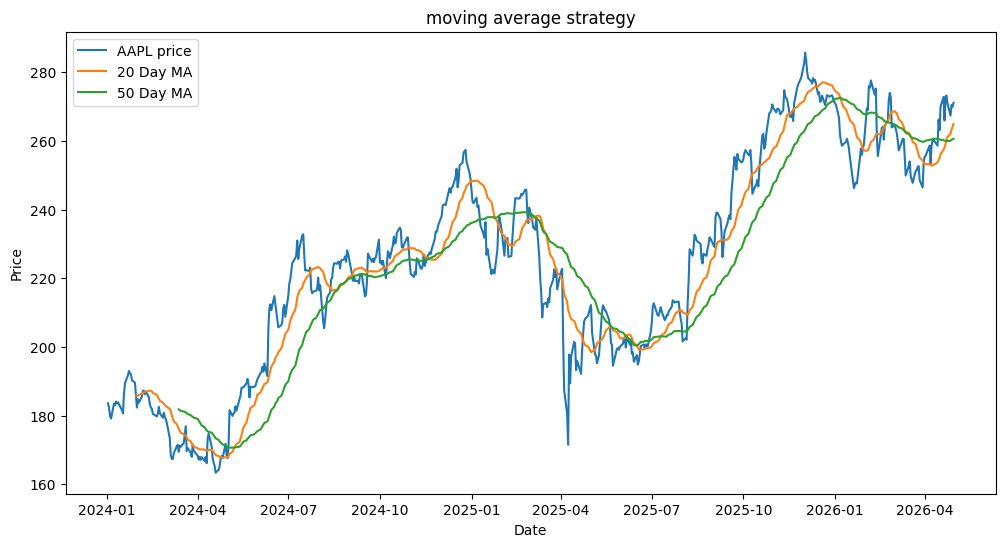

In [18]:
aapl_price = close['AAPL']

ma20 = aapl_price.rolling(window=20).mean()
ma50 = aapl_price.rolling(window=50).mean()

plt.figure(figsize=(12,6))

plt.plot(aapl_price,label='AAPL price')
plt.plot(ma20,label='20 Day MA')
plt.plot(ma50,label='50 Day MA')

plt.title("moving average strategy")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("moving_average_strategy.png",bbox_inches='tight')
plt.show()

In [31]:
import yfinance as yf
import pandas as pd

aapl = yf.download('AAPL', start='2024-01-01', end='2026-05-01')
msft = yf.download('MSFT', start='2024-01-01', end='2026-05-01')
nvda = yf.download('NVDA', start='2024-01-01', end='2026-05-01')

close = pd.DataFrame()
close['AAPL'] = aapl['Close'].squeeze()
close['MSFT'] = msft['Close'].squeeze()
close['NVDA'] = nvda['Close'].squeeze()

# ── Backtest for one stock ──────────────────────
def backtest(ticker):
    price = close[ticker]

    ma20 = price.rolling(20).mean()
    ma50 = price.rolling(50).mean()

    signal = (ma20 > ma50).astype(int).shift(1)

    daily_ret = price.pct_change()
    strat_ret = signal * daily_ret

    total_start = (1 + strat_ret).cumprod().iloc[-1]-1
    total_bh = (1 + daily_ret).cumprod().iloc[-1]-1

    sharpe = (strat_ret.mean() / strat_ret.std()) * (252 ** 0.5)

    roll_max = (1 + strat_ret).cumprod().cummax()
    drawdown = ((1 + strat_ret).cumprod() - roll_max) / roll_max
    max_dd = drawdown.min()
    wins = (strat_ret[strat_ret != 0] > 0).sum()
    total_trades = (strat_ret != 0).sum()
    win_rate = wins / total_trades * 100

    print(f"\n{ticker}")
    print(f" strategy return : {total_start*100:.1f}%")
    print(f"Buy and Hold     : {total_bh*100:.1f}%")
    print(f"Sharpe Ratio     : {sharpe:.2f}")
    print(f"Max Drawdown     : {max_dd*100:.1f}%")
    print(f"Win Rate         : {win_rate:.1f}%")

backtest('AAPL')
backtest('MSFT')
backtest('NVDA')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


AAPL
 strategy return : 20.4%
Buy and Hold     : 47.7%
Sharpe Ratio     : 0.55
Max Drawdown     : -24.6%
Win Rate         : 55.2%

MSFT
 strategy return : -9.1%
Buy and Hold     : 11.8%
Sharpe Ratio     : -0.28
Max Drawdown     : -19.4%
Win Rate         : 50.8%

NVDA
 strategy return : 64.6%
Buy and Hold     : 314.6%
Sharpe Ratio     : 0.83
Max Drawdown     : -23.5%
Win Rate         : 52.6%


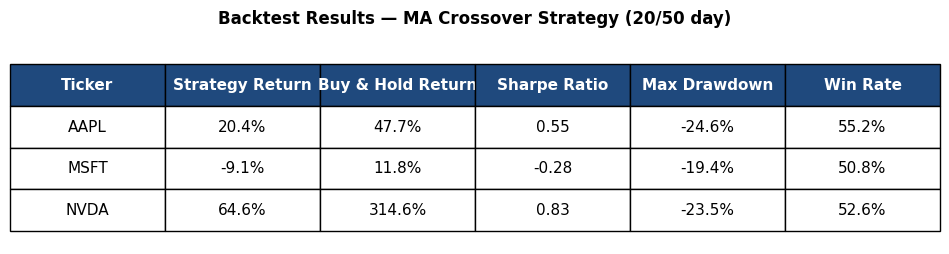

In [33]:
import matplotlib.pyplot as plt

data = [
    ['AAPL', '20.4%', '47.7%', '0.55', '-24.6%', '55.2%'],
    ['MSFT', '-9.1%', '11.8%', '-0.28', '-19.4%', '50.8%'],
    ['NVDA', '64.6%', '314.6%', '0.83', '-23.5%', '52.6%']
]

cols = ['Ticker', 'Strategy Return', 'Buy & Hold Return', 'Sharpe Ratio', 'Max Drawdown','Win Rate']

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

table = ax.table(cellText=data, colLabels=cols, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.5)

for j in range(len(cols)):
    table[0, j].set_facecolor('#1F497D')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.title('Backtest Results — MA Crossover Strategy (20/50 day)', 
          fontweight='bold', fontsize=12, pad=20)
plt.savefig('my_backtest_table.png', dpi=150, bbox_inches='tight')
plt.show()